# Modelos de clasificación y técnicas de balanceo



In [1]:
import json
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,brier_score_loss, confusion_matrix, f1_score, precision_recall_curve,precision_score, roc_auc_score, roc_curve,)
from sklearn.model_selection import(GridSearchCV, StratifiedKFold, cross_val_predict, train_test_split,)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import (FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler,)
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, InstanceHardnessThreshold
from imblearn.pipeline import Pipeline as ImbPipeline
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
SEMILLA = 42
N_PLIEGUES = 5
TAM_MUESTRA_BUSQUEDA = 120_000

## 2. División train/test



In [2]:
datos = pd.read_csv('DatosUsados/lc_loans_2016_2018.csv', low_memory=False)
datos['issue_d'] = pd.to_datetime(datos['issue_d'])
datos['dti_n'] = datos['dti_n'].replace(999, np.nan)

num_cols = ['revenue', 'dti_n', 'loan_amnt', 'fico_n']
cat_cols = ['emp_length', 'purpose', 'home_ownership_n', 'addr_state']
predictores = num_cols + cat_cols

X = datos[predictores].copy()
y = datos['Default'].astype(int).copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEMILLA,)
print(f'Train: {len(X_train):,} ({len(X_train) / len(X)})')
print(f'Test:  {len(X_test):,} ({len(X_test) / len(X)})')
print(f'Impago train: {y_train.mean()}')
print(f'Impago test:  {y_test.mean()}')

Train: 414,667 (0.7999996141484063)
Test:  103,667 (0.20000038585159377)
Impago train: 0.22415576836353027
Impago test:  0.22415040466107827


In [3]:
cv = StratifiedKFold(n_splits=N_PLIEGUES, shuffle=True, random_state=SEMILLA)
X_busqueda, _, y_busqueda, _ = train_test_split(X_train,y_train,train_size=TAM_MUESTRA_BUSQUEDA,stratify=y_train,random_state=SEMILLA,)
ratio_clases = (y_busqueda == 0).sum() / (y_busqueda == 1).sum()
print(f'Muestra para GridSearchCV: {len(X_busqueda):,}')
print(f'Ratio pagado/impago: {ratio_clases:.2f}:1')

Muestra para GridSearchCV: 120,000
Ratio pagado/impago: 3.46:1


## 3. Preprocesamiento

In [4]:
def pipeline_numerico():
    return SkPipeline([
        ('imputar', SimpleImputer(strategy='median')),
        ('escalar', StandardScaler()),
    ])

def pipeline_numerico_log():
    return SkPipeline([
        ('imputar', SimpleImputer(strategy='median')),
        ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('escalar', StandardScaler()),
    ])


preprocesador = ColumnTransformer([
    ('revenue', pipeline_numerico_log(), ['revenue']),
    ('dti', pipeline_numerico_log(), ['dti_n']),
    ('num', pipeline_numerico(), ['loan_amnt', 'fico_n']),
    ('cat', SkPipeline([
        ('imputar', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32)),
    ]), cat_cols),
], remainder='drop')

In [5]:
def crear_pipeline(clasificador):
    return ImbPipeline([
        ('pre', preprocesador),
        ('sampler', 'passthrough'),
        ('clf', clasificador),
    ])

samplers = [
    'passthrough',
    RandomOverSampler(random_state=SEMILLA),
    RandomUnderSampler(random_state=SEMILLA),
    InstanceHardnessThreshold(random_state=SEMILLA, cv=N_PLIEGUES),
]
nombres_samplers = {
    'passthrough': 'Sin balanceo',
    'RandomOverSampler': 'Random Oversampling',
    'RandomUnderSampler': 'Random Undersampling',
    'InstanceHardnessThreshold': 'Instance Hardness Threshold',
}

def nombre_balanceo(sampler):
    if sampler == 'passthrough':
        return 'Sin balanceo'
    return nombres_samplers[type(sampler).__name__]

## 4. Búsqueda de hiperparámetros



In [6]:
modelos = {
    'Regresión Logística': {
        'pipeline': crear_pipeline(LogisticRegression(
            solver='liblinear', max_iter=3000, random_state=SEMILLA,
        )),
        'param_grid': {
            'sampler': samplers,
            'clf__C': [0.05, 0.2, 1.0],
            'clf__penalty': ['l1', 'l2'],
        },
    },
    'LightGBM': {
        'pipeline': crear_pipeline(LGBMClassifier(
            objective='binary', random_state=SEMILLA, n_jobs=1, verbose=-1,
            n_estimators=400, subsample=0.85, subsample_freq=1,
            colsample_bytree=0.85,
        )),
        'param_grid': {
            'sampler': samplers,
            'clf__learning_rate': [0.03, 0.07],
            'clf__num_leaves': [15, 31],
        },
    },
    'XGBoost': {
        'pipeline': crear_pipeline(XGBClassifier(
            objective='binary:logistic', eval_metric='logloss', tree_method='hist',
            random_state=SEMILLA, n_jobs=1, n_estimators=400,
            subsample=0.85, colsample_bytree=0.85,
            min_child_weight=10, reg_lambda=1.0,
        )),
        'param_grid': {
            'sampler': samplers,
            'clf__learning_rate': [0.03, 0.07],
            'clf__max_depth': [3, 5],
        },
    },
    'Red neuronal MLP profunda': {
        'pipeline': crear_pipeline(MLPClassifier(
            random_state=SEMILLA, early_stopping=True,
            validation_fraction=0.10, n_iter_no_change=12,
            max_iter=200, batch_size=512,
        )),
        'param_grid': {
            'sampler': samplers,
            'clf__hidden_layer_sizes': [(64, 32), (128, 64, 32)],
            'clf__alpha': [1e-4, 1e-3],
            'clf__learning_rate_init': [1e-3],
        },
    },
    'Naive Bayes gaussiano': {
        'pipeline': crear_pipeline(GaussianNB()),
        'param_grid': {
            'sampler': samplers,
            'clf__var_smoothing': [1e-10, 1e-9, 1e-8],
        },
    },
}

total_configuraciones = sum(
    np.prod([len(v) for v in spec['param_grid'].values()])
    for spec in modelos.values()
)
print(f'Modelos: {len(modelos)}')
print(f'Técnicas de balanceo: {len(samplers)}')
print(f'Configuraciones: {total_configuraciones}')

Modelos: 5
Técnicas de balanceo: 4
Configuraciones: 84


## 5. GridSearchCV



In [7]:
metricas_cv = {'AP': 'average_precision','ROC_AUC': 'roc_auc','Accuracy': 'accuracy','Balanced_accuracy': 'balanced_accuracy','Precision': 'precision','Recall': 'recall','F1': 'f1',}
Path('results').mkdir(exist_ok=True)
busquedas = {}

for nombre, spec in modelos.items():
    print(f'Buscando: {nombre}')
    grid = GridSearchCV(
        estimator=spec['pipeline'],
        param_grid=spec['param_grid'],
        scoring=metricas_cv,
        refit='AP',
        cv=cv,
        n_jobs=-1,
        verbose=1,
        error_score='raise',
    )

    grid.fit(X_busqueda, y_busqueda)
    busquedas[nombre] = grid
    resultados = pd.DataFrame(grid.cv_results_)
    resultados['Balanceo'] = resultados['param_sampler'].apply(nombre_balanceo)
    ruta = Path('results') / f"grid_{nombre.lower().replace(' ', '_')}.csv"
    resultados.to_csv(ruta, index=False)

Buscando: Regresión Logística
Fitting 5 folds for each of 24 candidates, totalling 120 fits


c:\Users\corre\OneDrive\Documentos\workspace_lucia\TFM\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Buscando: LightGBM
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Buscando: XGBoost
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Buscando: Red neuronal MLP profunda
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Buscando: Naive Bayes gaussiano
Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [8]:
filas = []

for nombre in modelos:
    resultados = pd.read_csv(
        Path('results') / f"grid_{nombre.lower().replace(' ', '_')}.csv"
    )

    for tecnica, grupo in resultados.groupby('Balanceo'):
        mejor = grupo.loc[grupo['mean_test_AP'].idxmax()]

        filas.append({
            'Modelo': nombre,
            'Balanceo': tecnica,
            'AP_CV': mejor['mean_test_AP'],
            'AP_std': mejor['std_test_AP'],
            'ROC_AUC_CV': mejor['mean_test_ROC_AUC'],
            'Accuracy_CV': mejor['mean_test_Accuracy'],
            'Balanced_accuracy_CV': mejor['mean_test_Balanced_accuracy'],
            'Precision_CV': mejor['mean_test_Precision'],
            'Recall_CV': mejor['mean_test_Recall'],
            'F1_CV': mejor['mean_test_F1'],
            'Parametros': mejor['params'],
        })

resumen_cv = (
    pd.DataFrame(filas)
    .sort_values('AP_CV', ascending=False)
    .reset_index(drop=True)
)

resumen_cv.to_csv('results/resumen_modelos_balanceo_cv.csv',index=False,)
vista_cv = resumen_cv.copy()
vista_cv['AP_CV'] = [
    f'{media:.4f} ({std:.4f})'
    for media, std in zip(
        resumen_cv['AP_CV'],
        resumen_cv['AP_std'],
    )
]
vista_cv = vista_cv.drop(columns='AP_std')
display(vista_cv.round(4))

,Modelo,Balanceo,AP_CV,ROC_AUC_CV,Accuracy_CV,Balanced_accuracy_CV,Precision_CV,Recall_CV,F1_CV,Parametros
0,LightGBM,Sin balanceo,0.3646 (0.0071),0.6761,0.7769,0.5109,0.5460,0.0288,0.0547,"{'clf__learning_rate': 0.03, 'clf__num_leaves'..."
1,XGBoost,Sin balanceo,0.3645 (0.0071),0.6756,0.7769,0.5127,0.5381,0.0337,0.0635,"{'clf__learning_rate': 0.03, 'clf__max_depth':..."
2,XGBoost,Random Oversampling,0.3643 (0.0074),0.6753,0.6178,0.6234,0.3213,0.6338,0.4264,"{'clf__learning_rate': 0.07, 'clf__max_depth':..."
3,LightGBM,Random Oversampling,0.3640 (0.0068),0.6751,0.6151,0.6249,0.3209,0.6425,0.4280,"{'clf__learning_rate': 0.03, 'clf__num_leaves'..."
4,LightGBM,Random Undersampling,0.3633 (0.0076),0.6746,0.6104,0.6237,0.3185,0.6479,0.4271,"{'clf__learning_rate': 0.03, 'clf__num_leaves'..."
5,XGBoost,Random Undersampling,0.3631 (0.0071),0.6745,0.6136,0.6229,0.3194,0.6399,0.4261,"{'clf__learning_rate': 0.07, 'clf__max_depth':..."
6,LightGBM,Instance Hardness Threshold,0.3608 (0.0053),0.6733,0.5107,0.6138,0.2876,0.8007,0.4232,"{'clf__learning_rate': 0.03, 'clf__num_leaves'..."
7,XGBoost,Instance Hardness Threshold,0.3606 (0.0049),0.6731,0.5098,0.6134,0.2872,0.8010,0.4228,"{'clf__learning_rate': 0.07, 'clf__max_depth':..."
8,Red neuronal MLP profunda,Sin balanceo,0.3598 (0.0087),0.6723,0.7763,0.5140,0.5146,0.0386,0.0715,"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes..."
9,Red neuronal MLP profunda,Random Undersampling,0.3584 (0.0048),0.6716,0.6010,0.6223,0.3149,0.6609,0.4262,"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes..."


In [9]:
matriz_pr = resumen_cv.pivot(index='Modelo', columns='Balanceo', values='AP_CV')
matriz_recall = resumen_cv.pivot(index='Modelo', columns='Balanceo', values='Recall_CV')
matriz_f1 = resumen_cv.pivot(index='Modelo', columns='Balanceo', values='F1_CV')

display(matriz_pr.round(4))
print('Recall de impago con umbral 0,5')
display(matriz_recall.round(4))
print('F1 de impago con umbral 0,5')
display(matriz_f1.round(4))

Balanceo,Instance Hardness Threshold,Random Oversampling,Random Undersampling,Sin balanceo
Modelo,,,,
LightGBM,0.3608,0.3640,0.3633,0.3646
Naive Bayes gaussiano,0.2688,0.2728,0.2728,0.2731
Red neuronal MLP profunda,0.3551,0.3115,0.3584,0.3598
Regresión Logística,0.3528,0.3550,0.3550,0.3557
XGBoost,0.3606,0.3643,0.3631,0.3645


Recall de impago con umbral 0,5


Balanceo,Instance Hardness Threshold,Random Oversampling,Random Undersampling,Sin balanceo
Modelo,,,,
LightGBM,0.8007,0.6425,0.6479,0.0288
Naive Bayes gaussiano,0.6243,0.8194,0.8155,0.7239
Red neuronal MLP profunda,0.7874,0.5842,0.6609,0.0386
Regresión Logística,0.7988,0.6425,0.6447,0.0242
XGBoost,0.8010,0.6338,0.6399,0.0337


F1 de impago con umbral 0,5


Balanceo,Instance Hardness Threshold,Random Oversampling,Random Undersampling,Sin balanceo
Modelo,,,,
LightGBM,0.4232,0.4280,0.4271,0.0547
Naive Bayes gaussiano,0.3778,0.3784,0.3775,0.3808
Red neuronal MLP profunda,0.4229,0.3925,0.4262,0.0715
Regresión Logística,0.4191,0.4219,0.4226,0.0462
XGBoost,0.4228,0.4264,0.4261,0.0635


## 6. Selección 

In [10]:
mejor_fila = resumen_cv.iloc[0]
nombre_ganador = mejor_fila['Modelo']
balanceo_ganador = mejor_fila['Balanceo']
mejor_pipeline = clone(busquedas[nombre_ganador].best_estimator_)

print(f'Modelo seleccionado {nombre_ganador}')
print(f'Técnica de balanceo {balanceo_ganador}')
print(f'AP CV: {mejor_fila["AP_CV"]:.4f} 'f'± {mejor_fila["AP_std"]:.4f}')
print('Mejores hiperparámetros:')
print(busquedas[nombre_ganador].best_params_)

Modelo seleccionado LightGBM
Técnica de balanceo Sin balanceo
AP CV: 0.3646 ± 0.0071
Mejores hiperparámetros:
{'clf__learning_rate': 0.03, 'clf__num_leaves': 15, 'sampler': 'passthrough'}


## Umbral de decisión

In [11]:
def buscar_umbral_gmean(y_true, prob):
    fpr, tpr, umbrales = roc_curve(y_true, prob)
    gmean = np.sqrt(tpr * (1 - fpr))
    i = np.nanargmax(gmean)
    return float(umbrales[i]), float(gmean[i])

prob_oof = cross_val_predict(mejor_pipeline, X_train, y_train,cv=cv, method='predict_proba', n_jobs=-1,)[:, 1]
umbral_oof, gmean_oof = buscar_umbral_gmean(y_train, prob_oof)
print(f'Umbral G-mean obtenido con predicciones out-of-fold: {umbral_oof:.4f}')
print(f'G-mean OOF correspondiente: {gmean_oof:.4f}')

Umbral G-mean obtenido con predicciones out-of-fold: 0.2280
G-mean OOF correspondiente: 0.6290


## 7. Ajuste final y evaluación en test



In [12]:
modelo_final = clone(mejor_pipeline)
modelo_final.fit(X_train, y_train)
prob_test = modelo_final.predict_proba(X_test)[:, 1]

def calcular_metricas(y_true, prob, umbral=0.5):
    pred = (prob >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    especificidad = tn / (tn + fp)
    sensibilidad = tp / (tp + fn)
    return {
        'Umbral': umbral,
        'AP': average_precision_score(y_true, prob),
        'ROC-AUC': roc_auc_score(y_true, prob),
        'Gini': 2 * roc_auc_score(y_true, prob) - 1,
        'Brier': brier_score_loss(y_true, prob),
        'Accuracy': accuracy_score(y_true, pred),
        'Balanced accuracy': balanced_accuracy_score(y_true, pred),
        'Precisión impago': precision_score(y_true, pred, zero_division=0),
        'Recall impago': sensibilidad,
        'Especificidad': especificidad,
        'F1 impago': f1_score(y_true, pred, zero_division=0),
        'G-mean': np.sqrt(sensibilidad * especificidad),
        '% clasificado como impago': pred.mean(),
    }

metricas_test_05 = calcular_metricas(y_test, prob_test, 0.5)
metricas_test_oof = calcular_metricas(y_test, prob_test, umbral_oof)
tabla_test = pd.DataFrame([metricas_test_05, metricas_test_oof],index=['Umbral 0,5', f'Umbral G-mean (train OOF) = {umbral_oof:.3f}'],)
display(tabla_test.round(4))
pred_test = (prob_test >= umbral_oof).astype(int)

c:\Users\corre\OneDrive\Documentos\workspace_lucia\TFM\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Umbral,AP,ROC-AUC,Gini,Brier,Accuracy,Balanced accuracy,Precisión impago,Recall impago,Especificidad,F1 impago,G-mean,% clasificado como impago
"Umbral 0,5",0.500,0.3695,0.6816,0.3632,0.1613,0.7769,0.5116,0.5428,0.0306,0.9926,0.0579,0.1741,0.0126
Umbral G-mean (train OOF) = 0.228,0.228,0.3695,0.6816,0.3632,0.1613,0.6241,0.6296,0.3270,0.6396,0.6197,0.4327,0.6296,0.4384


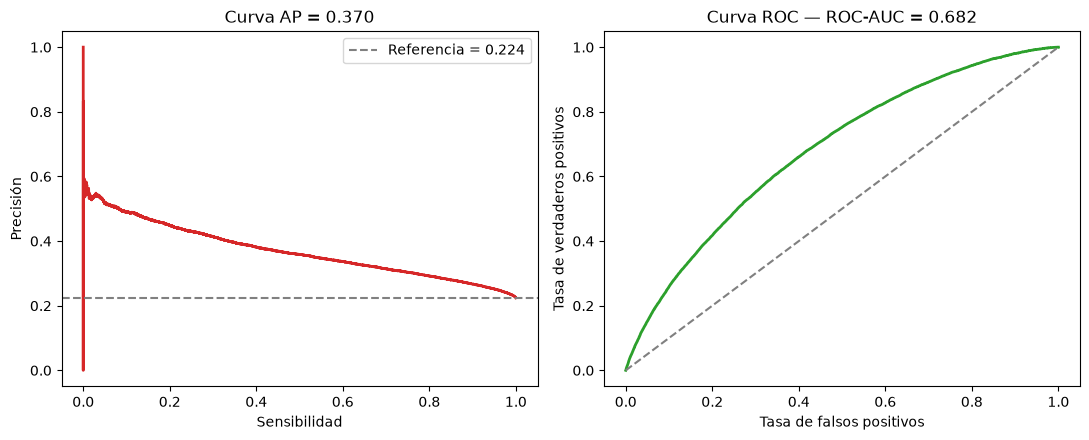

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

precision, recall, _ = precision_recall_curve(y_test, prob_test)
axes[0].plot(recall, precision, color='tab:red', lw=2)
axes[0].axhline(y_test.mean(), color='gray', linestyle='--',
                label=f'Referencia = {y_test.mean():.3f}')
axes[0].set_xlabel('Sensibilidad')
axes[0].set_ylabel('Precisión')
axes[0].set_title(f'Curva AP = {average_precision_score(y_test, prob_test):.3f}')
axes[0].legend()

fpr, tpr, _ = roc_curve(y_test, prob_test)
axes[1].plot(fpr, tpr, color='tab:green', lw=2)
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('Tasa de falsos positivos')
axes[1].set_ylabel('Tasa de verdaderos positivos')
axes[1].set_title(f'Curva ROC — ROC-AUC = {roc_auc_score(y_test, prob_test):.3f}')

plt.tight_layout()
plt.show()

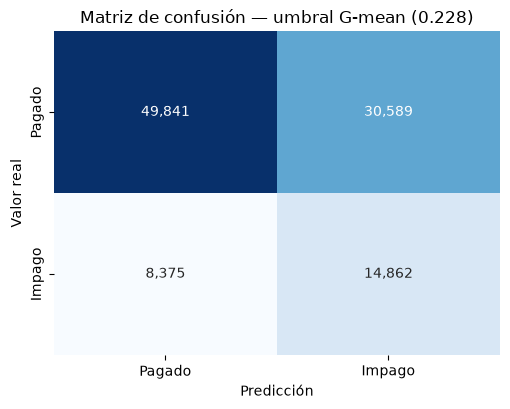

In [14]:
matriz = confusion_matrix(y_test, pred_test)
fig, ax = plt.subplots(figsize=(5.2, 4.2))
sns.heatmap(
    matriz, annot=True, fmt=',', cmap='Blues', cbar=False, ax=ax,
    xticklabels=['Pagado', 'Impago'], yticklabels=['Pagado', 'Impago'],
)
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor real')
ax.set_title(f'Matriz de confusión — umbral G-mean ({umbral_oof:.3f})')
plt.tight_layout()
plt.show()

## 8. Guardado


In [15]:
Path('models').mkdir(exist_ok=True)
Path('results').mkdir(exist_ok=True)

joblib.dump(modelo_final, 'models/modelo_scoring_final.joblib')

mejores_params = busquedas[nombre_ganador].best_params_
params_finales = {
    k: (list(v) if isinstance(v, tuple) else v)
    for k, v in mejores_params.items()
}

resumen_guardado = {
    'modelo': nombre_ganador,
    'balanceo': balanceo_ganador,
    'hiperparametros': params_finales,
    'criterio_seleccion': 'AP media en validación cruzada estratificada de 5 pliegues',
    'umbral_gmean_train_oof': float(umbral_oof),
    'metricas_test_umbral_05': {k: float(v) for k, v in metricas_test_05.items()},
    'metricas_test_umbral_gmean': {k: float(v) for k, v in metricas_test_oof.items()},
    'predictores': predictores,
    'seed': SEMILLA,
}

with open('models/resumen_modelo_final.json', 'w', encoding='utf-8') as f:
    json.dump(resumen_guardado, f, indent=2, ensure_ascii=False)

tabla_test.to_csv('results/metricas_test_modelo_final.csv')

print('Guardado: models/modelo_scoring_final.joblib')
print('Guardado: models/resumen_modelo_final.json')
print('Guardado: results/resumen_modelos_balanceo_cv.csv')
print('Guardado: results/metricas_test_modelo_final.csv')

Guardado: models/modelo_scoring_final.joblib
Guardado: models/resumen_modelo_final.json
Guardado: results/resumen_modelos_balanceo_cv.csv
Guardado: results/metricas_test_modelo_final.csv
